# **EEG-Based Multi-Class Emotion Recognition Using Machine Learning**

In [51]:
os.chdir("/content/drive/MyDrive/Healthcare/HealthCare")
!pwd
!git add .
!git commit -m "Problem Statement Defined, Data Acquisition, Exploratory Data Analysis (EDA),  Data Cleaning and Feature Selection Implemented"

/content/drive/MyDrive/Healthcare/HealthCare
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@1921798a67a1.(none)')


In [ ]:
git config --global user.email "yosefenadagim@gmail.com"
git config --global user.name "Tewodros"

# 1. Problem Statement

### This project focuses on recognizing human emotions from EEG signals by classifying them into five categories: Happy (1), Sad (2), Neutral (3), Angry (4), and Fear (5). EEG signals are complex, high-dimensional, and often noisy, making accurate emotion classification challenging. The goal is to preprocess the data, extract meaningful features, and train machine learning models such as Support Vector Machine (SVM) and Random Forest, using cross-validation during training to ensure robust performance. The models will be evaluated to identify the best-performing approach for automated emotion recognition, enabling applications in affective computing, mental health monitoring, and brain-computer interfaces.

# 2. Data Acquisition

In [3]:
# Import Libraries

from google.colab import drive
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [1]:
# Connect with my drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [28]:
# Import dataset
os.chdir("/content/drive/MyDrive/Healthcare")
df = pd.read_excel('EEG-data.xlsx')
print(df.head(5))

   Unnamed: 0   X1   X2   X3   X4   X5   X6   X7   X8   X9  ...  X4086  X4087  \
0           0  -56  -50  -64  -91 -135 -140 -134 -114 -115  ...    -37    -43   
1           1   14   25   31   36   33   33   27   27   21  ...    -45    -32   
2           2 -159 -176 -174 -145 -101  -45    0   29   15  ...    -40    -25   
3           3   34   31   29   19   16   12    3   -1   -5  ...    -34    -33   
4           4   44   50   46   43   43   46   45   40   36  ...      4      5   

   X4088  X4089  X4090  X4091  X4092  X4093  X4094  y  
0    -63    -82   -114   -138   -159   -172   -180  5  
1     -6     -7     -2    -20    -34    -40    -40  5  
2     14     56     73     48    -12    -62   -100  4  
3    -29    -22    -18    -14    -10     -9      0  3  
4      6      6      2      1      0     -1     -4  2  

[5 rows x 4096 columns]


In [12]:
# Check if there are null data
print (f'Total sum of nulls: {df.isnull().sum().sum()}')

# Verify dataset format
df.info()

# check dataset size
df.shape

Total sum of nulls: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 4096 entries, Unnamed: 0 to y
dtypes: int64(4096)
memory usage: 15.6 MB


(500, 4096)

## 3. Exploratory Data Analysis (EDA)

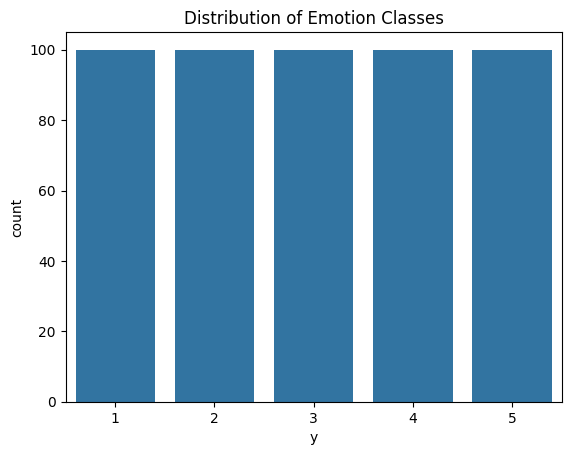

In [14]:
# Check the distribution of emotion classes

sns.countplot(x='y', data=df)
plt.title("Distribution of Emotion Classes")
plt.show()

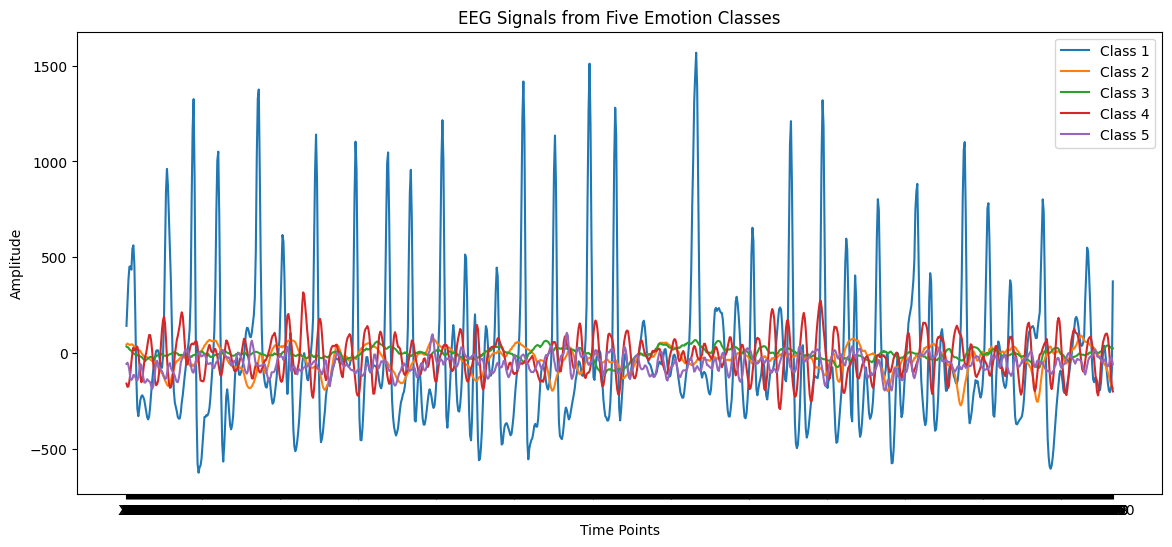

In [23]:
# Visualize Sample Signals from each class

# Define emotion classes
classes = [1, 2, 3, 4, 5]  # 1=Happy, 2=Sad, 3=Neutral, 4=Angry, 5=Fear

plt.figure(figsize=(14, 6))

# Plot one sample from each class
for c in classes:
    sample = df[df['y'] == c].iloc[0]  # take first sample of each class
    signal = sample['X1':'X1000']       # first 1000 time points for clarity
    plt.plot(signal, label=f"Class {c}")

plt.title("EEG Signals from Five Emotion Classes")
plt.xlabel("Time Points")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

## 4. Data Cleaning

In [29]:
# Remove the first unnamed column
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head(5)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094,y
0,-56,-50,-64,-91,-135,-140,-134,-114,-115,-126,...,-37,-43,-63,-82,-114,-138,-159,-172,-180,5
1,14,25,31,36,33,33,27,27,21,24,...,-45,-32,-6,-7,-2,-20,-34,-40,-40,5
2,-159,-176,-174,-145,-101,-45,0,29,15,15,...,-40,-25,14,56,73,48,-12,-62,-100,4
3,34,31,29,19,16,12,3,-1,-5,-8,...,-34,-33,-29,-22,-18,-14,-10,-9,0,3
4,44,50,46,43,43,46,45,40,36,31,...,4,5,6,6,2,1,0,-1,-4,2


## 5. Feature Selection

In [42]:
# Compute correlation matrix
corr_matrix = df.drop(columns=['y']).corr().abs()
corr_matrix
# Select upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation > 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.96)]
print("Dropping", len(to_drop), "highly correlated features")

# Drop redundant features
df_reduced = df.drop(columns=to_drop)

Dropping 657 highly correlated features


In [43]:
print(f'Size of reduced dataset is: {df_reduced.shape}')
df_reduced.head(5)

Size of reduced dataset is: (500, 3438)


,X1,X2,X3,X6,X7,X8,X9,X10,X11,X12,...,X4084,X4085,X4086,X4087,X4089,X4090,X4091,X4092,X4093,y
0,-56,-50,-64,-140,-134,-114,-115,-126,-138,-143,...,-77,-49,-37,-43,-82,-114,-138,-159,-172,5
1,14,25,31,33,27,27,21,24,32,39,...,-67,-56,-45,-32,-7,-2,-20,-34,-40,5
2,-159,-176,-174,-45,0,29,15,15,29,34,...,-66,-56,-40,-25,56,73,48,-12,-62,4
3,34,31,29,12,3,-1,-5,-8,-8,-10,...,-28,-33,-34,-33,-22,-18,-14,-10,-9,3
4,44,50,46,46,45,40,36,31,26,21,...,-6,-4,4,5,6,2,1,0,-1,2


## **6. Dataset Splitting**
